# Wisconsin Breast Cancer Dataset

In [3]:
# ── 0. Imports ─────────────────────────────────────────────────────────────────
import numpy as np
from sklearn.datasets import load_breast_cancer

from config.config import N_QUBITS, N_LAYERS, N_POINTS, N_TRIALS, N_EPOCH, N_POPSIZE, N_PM, SEED
from config.experiments import ExperimentConfig

from src.data.preprocessing import preprocess
import src.data.saving as saving
from src.data.saving import candidate_exists, svm_exists, load_parameter_train, load_svm_results
from src.kernel.quantum_kernel import quantum_kernel_matrix_cross
from src.optimization.pipeline import get_candidate, get_svm_results
from src.optimization.classical_base import classical_baseline
import src.utils.visuals as visuals
from src.utils.visuals import plot_accuracy, plot_g_best, plot_expressibility, plot_kernel_heatmaps


In [4]:
# ── 1. Data ────────────────────────────────────────────────────────────────────

dataset = load_breast_cancer()
X_train, X_test, y_train, y_test = preprocess(dataset.data, dataset.target, N_QUBITS)

print(f"Dataset  : {dataset.target_names}")
print(f"Train    : {X_train.shape}  |  Test: {X_test.shape}")

RESULTS_DIR = 'Results/Wisconsin breast dataset v3'
saving.RESULTS_DIR = RESULTS_DIR
visuals.RESULTS_DIR = RESULTS_DIR

Dataset  : ['malignant' 'benign']
Train    : (398, 4)  |  Test: (171, 4)


In [5]:
# ── 2. Experiments ─────────────────────────────────────────────────────────────
# This is the main section to edit. Each ExperimentConfig defines one run.
# Comment out any you don't want to include.
#
# name             → used as the Results subfolder name; must be unique
# optimizer        → 'optuna' or 'mealpy'
# subset_method    → 'random', 'nystrom_global', or 'nystrom_stratified'
# subset_kwargs    → passed to the chosen subset function
# optimizer_kwargs → passed to the chosen optimizer
# load_from        → (optional) load candidate from a different experiment name

EXPERIMENTS: list[ExperimentConfig] = [
 
    # ── OPTUNA ────────────────────────────────────────────────────────────────
    ExperimentConfig(
        name             = 'optuna_random_haar',
        optimizer        = 'optuna',
        variant          = 'haar',
        subset_method    = 'random',
        subset_kwargs    = {'n_sample': N_POINTS, 'seed': SEED},
        optimizer_kwargs = {'n_trials': N_TRIALS, 'sample_mode': 'data'},
    ),
    # ExperimentConfig(
    #     name             = 'mealpy_random_haar',
    #     optimizer        = 'mealpy',
    #     variant          = 'haar',
    #     subset_method    = 'random',
    #     subset_kwargs    = {'n_sample': N_POINTS, 'seed': SEED},
    #     optimizer_kwargs = {'n_epoch': N_EPOCH, 'n_pop_size': N_POPSIZE, 'n_pm': N_PM, 'sample_mode': 'data'},
    # ),

    # ── Option 1 — geometric difference, for side-by-side comparison ───────
    ExperimentConfig(
        name             = 'optuna_random_geometric',
        optimizer        = 'optuna',
        variant          = 'geometric',
        subset_method    = 'random',
        subset_kwargs    = {'n_sample': N_POINTS, 'seed': SEED},
        optimizer_kwargs = {'n_trials': N_TRIALS},
    ),
]

In [7]:
# ── 3. Run ─────────────────────────────────────────────────────────────────────
# Cached results are reused automatically; delete Results/{name}/svm.pkl or
# Results/{name}/candidate.pkl to force a fresh run for that experiment.
 
summary = {}   # name → {accuracy, cv_acc, g_best, best_C}
 
# ── Classical baseline ──────────────────────────────────────────────────────
BASELINE = 'Classical_baseline'
if svm_exists(BASELINE):
    print(f"\nLoaded results of SVM for '{BASELINE}'")
    baseline_res = load_svm_results(BASELINE)
else:
    baseline_res = classical_baseline(X_train, y_train, X_test, y_test, name=BASELINE)

summary[BASELINE] = {
    'accuracy': baseline_res['accuracy'],
    'cv_acc':   float(baseline_res['best_cv_accuracy']),
    'best_C':   baseline_res['best_C'],
    'g_best':   float('nan'),
    'kl_haar':  float('nan'),
}

# ── Quantum experiments ─────────────────────────────────────────────────────
for config in EXPERIMENTS:
    print(f"\n{'─' * 60}")
    print(f" {config.name}  [{config.optimizer} + {config.variant} + {config.subset_method}]")
    print(f"{'─' * 60}")

    # Step 1: Candidate (train or load from cache)
    candidate, K_train, K_classical, X_sub, y_sub = get_candidate(config, X_train, y_train)
    fitness_best = load_parameter_train(config.name).get('g_best', float('nan'))

    # Step 2: SVM (run or load from cache)
    K_test = None
    if not svm_exists(config.name):
        print("Computing cross-kernel (test × subset)…")
        K_test = quantum_kernel_matrix_cross(X_test, X_sub, candidate)

    results = get_svm_results(config, K_train, y_sub, K_test, y_test)

    summary[config.name] = {
        'accuracy': results['accuracy'],
        'cv_acc':   float(results['best_cv_accuracy']),
        'best_C':   results['best_C'],
        # keep the two metrics in separate columns so plot_g_best and
        # plot_expressibility each only pick up their own variant's runs
        'g_best':   fitness_best if config.variant == 'geometric' else float('nan'),
        'kl_haar':  fitness_best if config.variant == 'haar' else float('nan'),
    }

[I 2026-07-17 10:22:36,146] A new study created in memory with name: no-name-a1254551-f4a4-4b0c-a15b-0d6ad4ccada3



Loaded results of SVM for 'Classical_baseline'

────────────────────────────────────────────────────────────
 optuna_random_haar  [optuna + haar + random]
────────────────────────────────────────────────────────────


[I 2026-07-17 10:22:45,731] Trial 0 finished with value: 11.247092522347216 and parameters: {'gate_0': 'H', 'angle_0': 2.9919358809681142, 'gate_1': 'I', 'angle_1': 2.813551743454, 'gate_2': 'H', 'angle_2': 3.174931446696446, 'gate_3': 'CNOT', 'angle_3': 0.49582576955218, 'gate_4': 'I', 'angle_4': 3.49554863967827, 'gate_5': 'H', 'angle_5': 1.1714155759306215, 'gate_6': 'RY', 'angle_6': 4.746086765692839, 'gate_7': 'H', 'angle_7': 2.783990891818523, 'gate_8': 'I', 'angle_8': 2.9717301354072587, 'gate_9': 'CNOT', 'angle_9': 2.664291073887682, 'gate_10': 'RX', 'angle_10': 3.918102503553895, 'gate_11': 'CNOT', 'angle_11': 6.143395919004387, 'gate_12': 'H', 'angle_12': 3.7845590250435506, 'gate_13': 'I', 'angle_13': 3.279696305910728, 'gate_14': 'H', 'angle_14': 3.72202839445171, 'gate_15': 'RZ', 'angle_15': 2.3297805938050478}. Best is trial 0 with value: 11.247092522347216.
[I 2026-07-17 10:22:58,176] Trial 1 finished with value: 13.110223147265307 and parameters: {'gate_0': 'RZ', 'angle

Saved candidate  → Results/Wisconsin breast dataset v3/optuna_random_haar/candidate.pkl
Computing cross-kernel (test × subset)…


[I 2026-07-17 10:45:40,639] A new study created in memory with name: no-name-23de3512-a6d3-48a5-a76f-b840dc01d9ea


Saved SVM        → Results/Wisconsin breast dataset v3/optuna_random_haar/svm.pkl

REPORT: optuna_random_haar | 100 trials
Best C            : 10
Best CV accuracy  : 0.9000
Test accuracy     : 0.8655
              precision    recall  f1-score   support

          -1       0.87      0.75      0.81        64
           1       0.86      0.93      0.90       107

    accuracy                           0.87       171
   macro avg       0.87      0.84      0.85       171
weighted avg       0.87      0.87      0.86       171


────────────────────────────────────────────────────────────
 optuna_random_geometric  [optuna + geometric + random]
────────────────────────────────────────────────────────────


[I 2026-07-17 10:45:42,385] Trial 0 finished with value: 2.4452937705757716 and parameters: {'gate_0': 'H', 'angle_0': 5.720585462485279, 'gate_1': 'RZ', 'angle_1': 0.24689582486476588, 'gate_2': 'H', 'angle_2': 2.6772251965712432, 'gate_3': 'H', 'angle_3': 2.611333973245262, 'gate_4': 'RZ', 'angle_4': 0.6473591013698514, 'gate_5': 'CNOT', 'angle_5': 1.7069124360436165, 'gate_6': 'CNOT', 'angle_6': 5.517462577695027, 'gate_7': 'RZ', 'angle_7': 1.947590486265, 'gate_8': 'CNOT', 'angle_8': 4.271055664550044, 'gate_9': 'CNOT', 'angle_9': 4.981487551339249, 'gate_10': 'RZ', 'angle_10': 4.184328371979091, 'gate_11': 'H', 'angle_11': 4.446326682688164, 'gate_12': 'CNOT', 'angle_12': 3.6462435884205497, 'gate_13': 'RZ', 'angle_13': 1.8202217728640122, 'gate_14': 'CNOT', 'angle_14': 3.273121680753107, 'gate_15': 'H', 'angle_15': 1.5891583787816508}. Best is trial 0 with value: 2.4452937705757716.
[I 2026-07-17 10:45:43,693] Trial 1 finished with value: 4.118061155625078 and parameters: {'gate_

Saved candidate  → Results/Wisconsin breast dataset v3/optuna_random_geometric/candidate.pkl
Computing cross-kernel (test × subset)…
Saved SVM        → Results/Wisconsin breast dataset v3/optuna_random_geometric/svm.pkl

REPORT: optuna_random_geometric | 100 trials
Best C            : 10
Best CV accuracy  : 0.9500
Test accuracy     : 0.8713
              precision    recall  f1-score   support

          -1       0.89      0.75      0.81        64
           1       0.86      0.94      0.90       107

    accuracy                           0.87       171
   macro avg       0.88      0.85      0.86       171
weighted avg       0.87      0.87      0.87       171



In [8]:
# ── 4. Summary table ───────────────────────────────────────────────────────────
 
def print_summary(summary: dict) -> None:
    W = 32
    print(f"\n{'═' * 84}")
    print(f"  {'EXPERIMENT':<{W}} {'TEST ACC':>9} {'CV ACC':>9} {'g_best':>9} {'KL(Haar)':>9} {'best C':>6}")
    print(f"{'─' * 84}")
    for name, s in summary.items():
        g  = f"{s['g_best']:9.2f}"  if not np.isnan(s['g_best'])  else f"{'—':>9}"
        kl = f"{s['kl_haar']:9.3f}" if not np.isnan(s['kl_haar']) else f"{'—':>9}"
        print(f"  {name:<{W}} {s['accuracy']:>9.4f} {s['cv_acc']:>9.4f} {g} {kl} {s['best_C']:>6}")
    print(f"{'═' * 84}\n")

print_summary(summary)


════════════════════════════════════════════════════════════════════════════════════
  EXPERIMENT                        TEST ACC    CV ACC    g_best  KL(Haar) best C
────────────────────────────────────────────────────────────────────────────────────
  Classical_baseline                  0.9415    0.9530         —         —     10
  optuna_random_haar                  0.8655    0.9000         —     1.796     10
  optuna_random_geometric             0.8713    0.9500     38.82         —     10
════════════════════════════════════════════════════════════════════════════════════



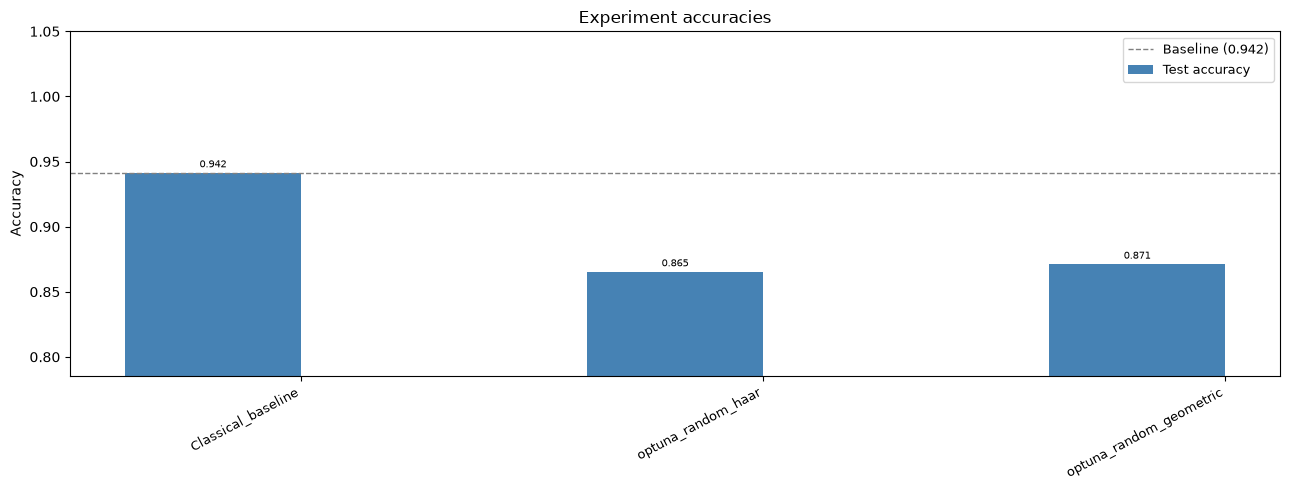

Saved → Results/Wisconsin breast dataset v3/accuracy_comparison.png


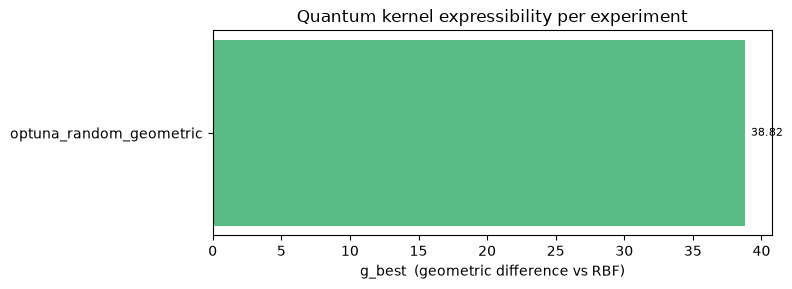

Saved → Results/Wisconsin breast dataset v3/g_best_comparison.png


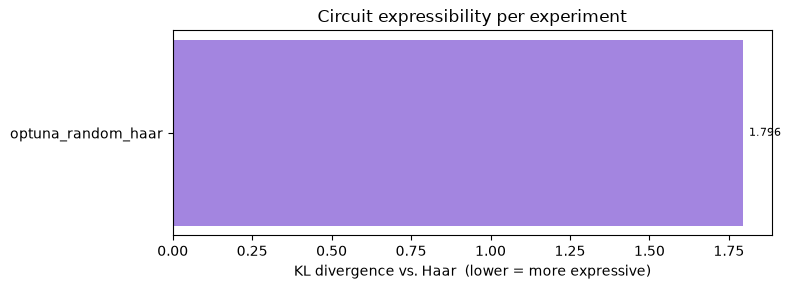

Saved → Results/Wisconsin breast dataset v3/expressibility_comparison.png


In [12]:
# ── 5. Visualizations ──────────────────────────────────────────────────────────

plot_accuracy(summary, ['test'])
plot_g_best(summary)          # Option 1 runs only
plot_expressibility(summary)  # Option 2 runs only
#plot_kernel_heatmaps(summary, max_show=3)